In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('data/weight-height.csv')
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Gender  10000 non-null  object 
 1   Height  10000 non-null  float64
 2   Weight  10000 non-null  float64
dtypes: float64(2), object(1)
memory usage: 234.5+ KB


In [6]:
df.shape

(10000, 3)

In [7]:
df.describe()

,Height,Weight
count,10000.000000,10000.000000
mean,66.367560,161.440357
std,3.847528,32.108439
min,54.263133,64.700127
25%,63.505620,135.818051
50%,66.318070,161.212928
75%,69.174262,187.169525
max,78.998742,269.989699


In [8]:
df.sample(5)

,Gender,Height,Weight
6487,Female,62.266592,138.381679
2142,Male,66.717422,181.824687
4836,Male,71.171153,213.457233
8597,Female,62.173708,136.266341
4481,Male,69.442300,174.885729


<Axes: xlabel='Height', ylabel='Count'>

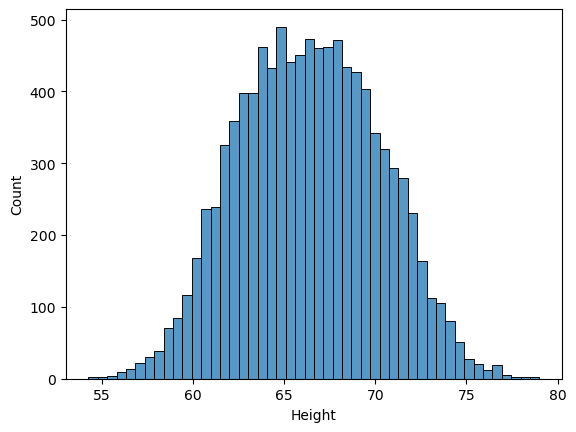

In [19]:
sns.histplot(x='Height',data=df)

<Axes: xlabel='Height', ylabel='Density'>

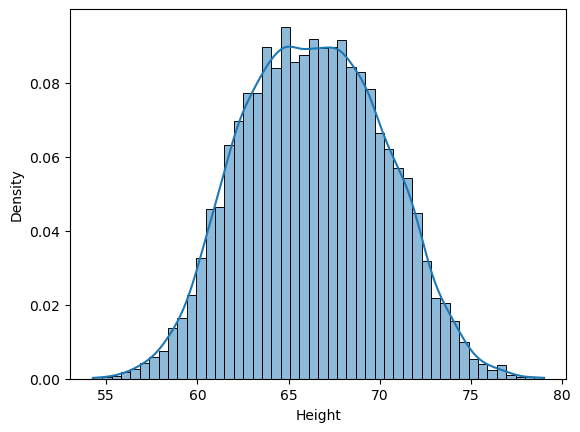

In [20]:
sns.histplot(x='Height',data=df,kde=True,stat='density')

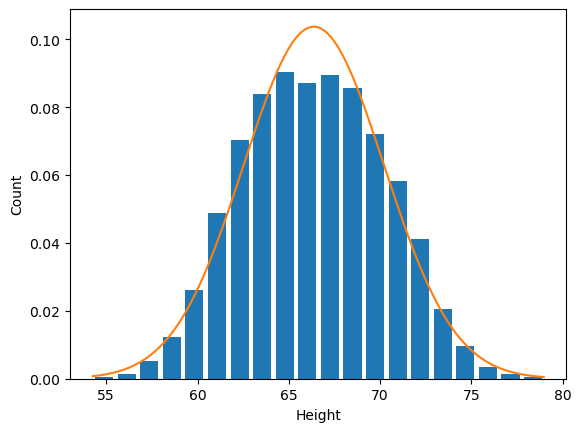

In [21]:
from scipy.stats import norm
plt.hist(x='Height',data=df,bins=20,rwidth=0.8,density=True)
plt.xlabel('Height')
plt.ylabel('Count')

rng=np.arange(df.Height.min(),df.Height.max(),0.1)
plt.plot(rng,norm.pdf(rng,df.Height.mean(),df.Height.std()))


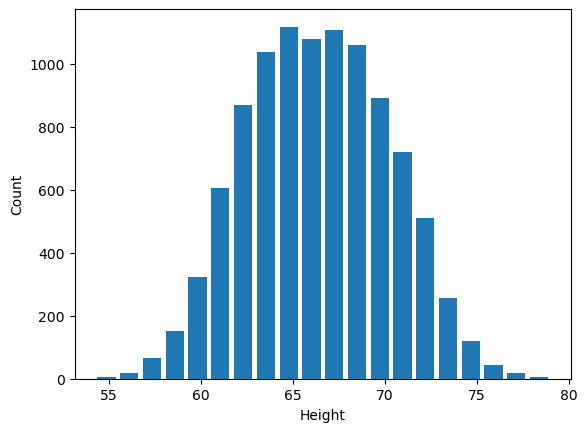

In [12]:
plt.hist(x='Height',data=df,bins=20,rwidth=0.8)
plt.xlabel('Height')
plt.ylabel('Count')
plt.show()

<Axes: ylabel='Height'>

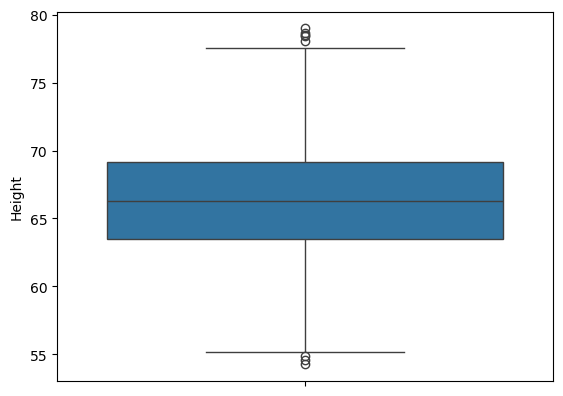

In [30]:
sns.boxplot(df['Height'])

In [23]:
mean_height=df['Height'].mean()
std_height=df['Height'].std()

upper_bound=mean_height+3*std_height
lower_bound=mean_height-3*std_height

In [31]:
df2=df[(df['Height']>lower_bound)&(df['Height']<upper_bound)]
df2.shape

(9993, 3)

In [40]:
df.shape[0]-df2.shape[0]

7

In [38]:
def detect_outliers_std(column):
    mean_height=df['Height'].mean()
    std_height=df['Height'].std()
    upper_bound=mean_height+3*std_height
    lower_bound=mean_height-3*std_height
    outliers=df[(df['Height']<lower_bound)|(df['Height']>upper_bound)]
    return outliers

height_outliers = detect_outliers_std('Height')
print(height_outliers)

      Gender     Height      Weight
994     Male  78.095867  255.690835
1317    Male  78.462053  227.342565
2014    Male  78.998742  269.989699
3285    Male  78.528210  253.889004
3757    Male  78.621374  245.733783
6624  Female  54.616858   71.393749
9285  Female  54.263133   64.700127


<Axes: ylabel='Height'>

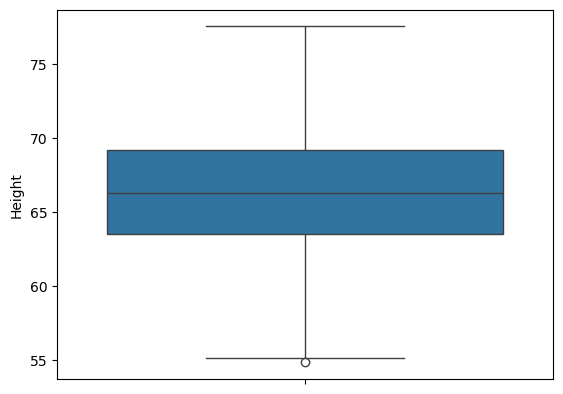

In [37]:
sns.boxplot(df2['Height'])

In [34]:
def detect_outliers_iqr(column):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers

height_outliers = detect_outliers_iqr('Height')
print(height_outliers)

      Gender     Height      Weight
994     Male  78.095867  255.690835
1317    Male  78.462053  227.342565
2014    Male  78.998742  269.989699
3285    Male  78.528210  253.889004
3757    Male  78.621374  245.733783
6624  Female  54.616858   71.393749
7294  Female  54.873728   78.606670
9285  Female  54.263133   64.700127


In [27]:
min_threshold=df['Height'].quantile(0.25)-1.5*(df['Height'].quantile(0.75)-df['Height'].quantile(0.25))
max_threshold=df['Height'].quantile(0.75)+1.5*(df['Height'].quantile(0.75)-df['Height'].quantile(0.25))
df3=df[(df['Height']<max_threshold)&(df['Height']>min_threshold)]

In [28]:
df3.shape

(9992, 3)

In [39]:
df.shape[0]-df3.shape[0]

8

<Axes: ylabel='Height'>

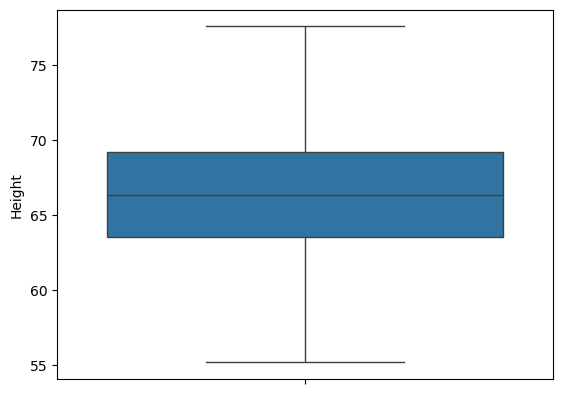

In [36]:
sns.boxplot(df3['Height'])

In [41]:
df['Z_score']=(df['Height']-df['Height'].mean())/df['Height'].std()
df.head()

,Gender,Height,Weight,Z_score
0,Male,73.847017,241.893563,1.943964
1,Male,68.781904,162.310473,0.627505
2,Male,74.110105,212.740856,2.012343
3,Male,71.730978,220.042470,1.393991
4,Male,69.881796,206.349801,0.913375


In [44]:
def detect_outliers_zscore(column):
    mean_height=df['Height'].mean()
    std_height=df['Height'].std()
    zscore=(df['Height']-mean_height)/std_height
    outliers=df[(zscore > 3) | (zscore < -3)]
    return outliers

height_outliers = detect_outliers_zscore('Height')
print(height_outliers)

      Gender     Height      Weight   Z_score
994     Male  78.095867  255.690835  3.048271
1317    Male  78.462053  227.342565  3.143445
2014    Male  78.998742  269.989699  3.282934
3285    Male  78.528210  253.889004  3.160640
3757    Male  78.621374  245.733783  3.184854
6624  Female  54.616858   71.393749 -3.054091
9285  Female  54.263133   64.700127 -3.146027
